**Cell 1 – Import libraries and load data**

What this does: Loads the three main data files and shows a preview.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set style for professional-looking charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Load the data
macro = pd.read_csv("../data/structured/macro_context.csv")
annual = pd.read_csv("../data/structured/annual.csv")
quarterly = pd.read_csv("../data/structured/quarterly.csv")

print("Macro shape:", macro.shape)
print("Annual shape:", annual.shape)
print("Quarterly shape:", quarterly.shape)
macro.head()

Macro shape: (6, 11)
Annual shape: (6, 22)
Quarterly shape: (24, 22)


,Period_ID,Year,Period_Type,GDP_Growth_Pct,Inflation_YoY_Pct,Policy_Rate_Pct,Cedi_USD_Avg,Cedi_USD_YoY_Change_Pct,Telecom_Sector_GDP_Share_Pct,Mobile_Penetration_Pct,Data_Penetration_Pct
0,2020FY,2020,Annual,0.5,9.9,14.5,5.73,-3.5,2.4,134,52
1,2021FY,2021,Annual,5.4,12.6,14.5,5.95,-3.8,2.5,140,58
2,2022FY,2022,Annual,3.1,54.1,27.0,8.95,-50.4,2.6,143,64
3,2023FY,2023,Annual,2.9,23.2,30.0,11.50,-28.5,2.8,145,68
4,2024FY,2024,Annual,5.7,23.8,27.0,14.80,-28.7,3.0,148,72


### Cell 2 – Section 1: Macro variable distributions (bar charts)

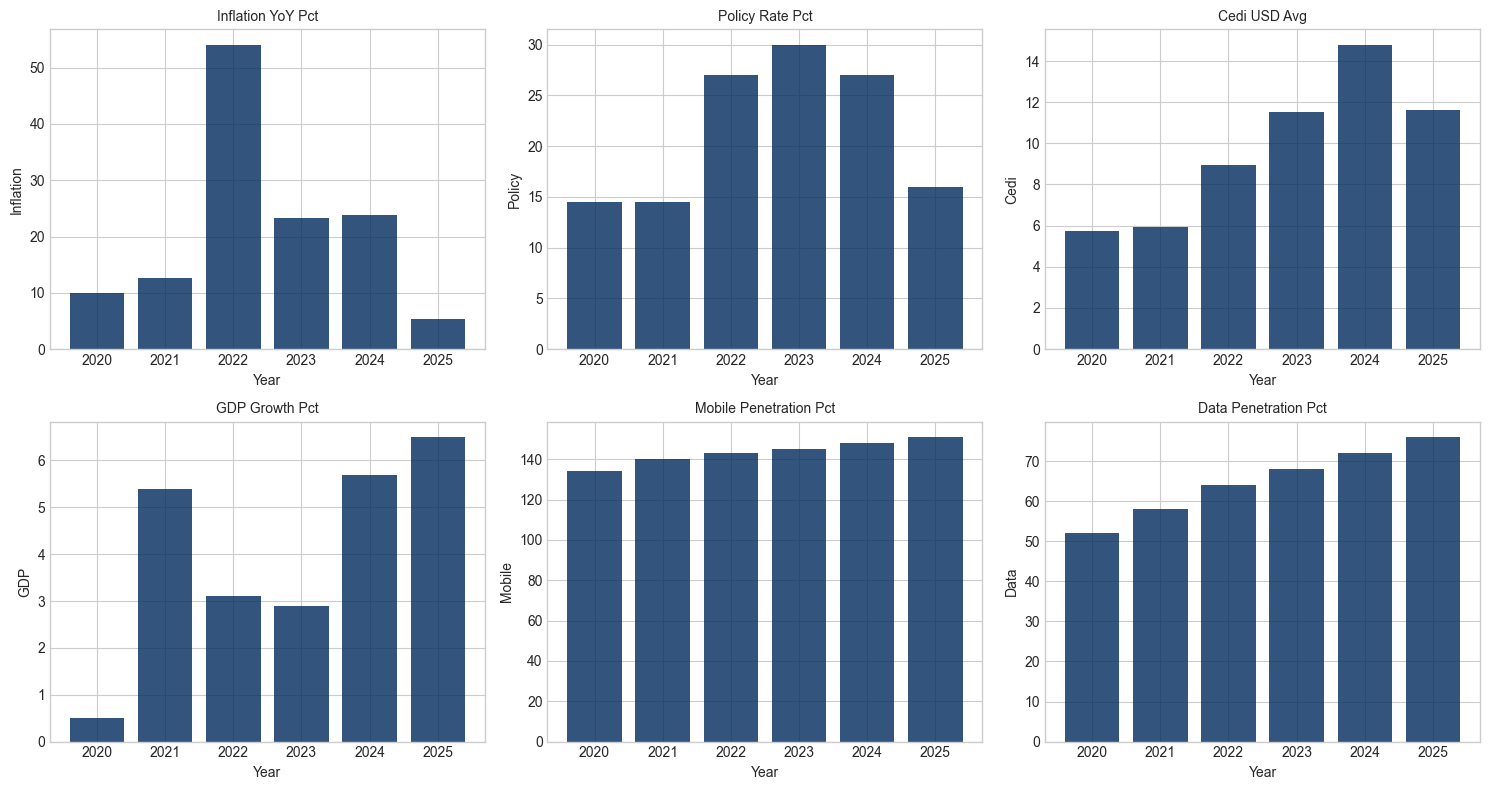

In [28]:

# Define the 6 macro variables from the master plan
macro_cols = ["Inflation_YoY_Pct", "Policy_Rate_Pct", "Cedi_USD_Avg",
              "GDP_Growth_Pct", "Mobile_Penetration_Pct", "Data_Penetration_Pct"]

# Create a 2x3 grid of bar charts
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(macro_cols):
    if col in macro.columns:
        axes[i].bar(macro["Year"], macro[col], color="#002B5C", alpha=0.8)
        axes[i].set_title(col.replace("_", " "), fontsize=10)
        axes[i].set_xlabel("Year")
        axes[i].set_ylabel(col.split("_")[0])  # simple unit
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.savefig("../notebooks/charts/macro_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Cell 3 – Section 2: Correlation matrix (macro → KPIs)

**Interpretation:** Look for strong positive (green) or negative (red) correlations. For example, Cedi depreciation (higher USD rate) might negatively impact EBITDA margin.


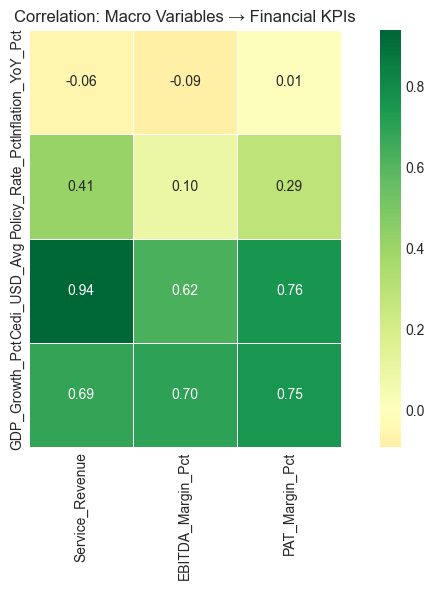

In [29]:
# Merge macro and annual data on Year
df_merged = macro.merge(annual, on="Year")

# Select macro features and target KPIs
feature_cols = ["Inflation_YoY_Pct", "Policy_Rate_Pct", "Cedi_USD_Avg", "GDP_Growth_Pct"]
target_cols = ["Service_Revenue", "EBITDA_Margin_Pct", "PAT_Margin_Pct"]

# Compute correlation matrix
corr_matrix = df_merged[feature_cols + target_cols].corr()

# Extract only macro-to-KPI correlations
macro_to_kpi = corr_matrix.loc[feature_cols, target_cols]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(macro_to_kpi, annot=True, cmap="RdYlGn", center=0, 
            fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation: Macro Variables → Financial KPIs")
plt.tight_layout()
plt.savefig("../notebooks/charts/correlation_heatmap.png", dpi=150)
plt.show()

### Cell 4 – Section 3: Lag analysis (inflation vs EBITDA margin)

**Expected insight:** You might find that inflation in the current quarter (lag 0) or previous quarter (lag 1) has a stronger correlation. This will help decide whether to use lagged features in the ML model.



In [38]:
# To ensure quarterly data is sorted by time
quarterly_sorted = quarterly.sort_values(["Year", "Quarter"])

# Merging inflation from macro (already loaded) into quarterly
quarterly_with_inflation = quarterly_sorted.merge(
    macro[["Year", "Inflation_YoY_Pct"]],   # use macro, not annual
    on="Year",
    how="left"
)

# Now check the merged DataFrame
if "Inflation_YoY_Pct" in quarterly_with_inflation.columns and "EBITDA_Margin_Pct" in quarterly_with_inflation.columns:
    print("Testing lag relationships (inflation → EBITDA margin)\n")
    for lag in range(0, 5):
        shifted = quarterly_with_inflation["Inflation_YoY_Pct"].shift(lag)
        valid = shifted.notna() & quarterly_with_inflation["EBITDA_Margin_Pct"].notna()
        if valid.sum() > 0:
            corr = shifted[valid].corr(quarterly_with_inflation.loc[valid, "EBITDA_Margin_Pct"])
            print(f"Lag {lag} quarter(s): correlation = {corr:.3f}")
        else:
            print(f"Lag {lag}: insufficient data")
else:
    print("Required columns not found in quarterly data. Check column names.")

Testing lag relationships (inflation → EBITDA margin)

Lag 0 quarter(s): correlation = -0.081
Lag 1 quarter(s): correlation = -0.079
Lag 2 quarter(s): correlation = -0.096
Lag 3 quarter(s): correlation = -0.040
Lag 4 quarter(s): correlation = 0.126


### Cell 5 – Section 4: Structural break identification (time series with annotations)

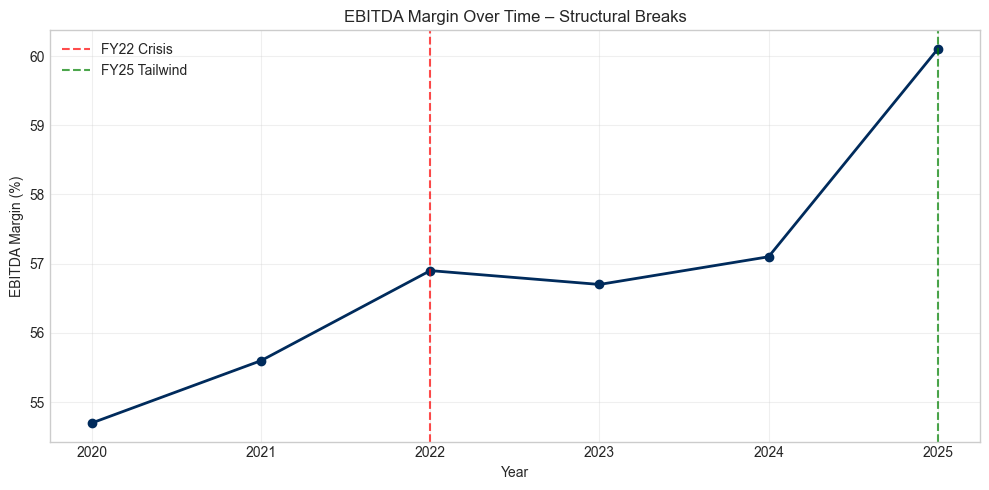

In [39]:
# Plot a key KPI over time (e.g., EBITDA Margin) with FY22 and FY25 marked
plt.figure(figsize=(10, 5))
plt.plot(annual["Year"], annual["EBITDA_Margin_Pct"], marker='o', linewidth=2, color="#002B5C")
#### Cell 5 – Section 4: Structural break identification (time series with annotations)
# Add vertical lines for FY22 and FY25
plt.axvline(x=2022, color='red', linestyle='--', alpha=0.7, label='FY22 Crisis')
plt.axvline(x=2025, color='green', linestyle='--', alpha=0.7, label='FY25 Tailwind')

plt.title("EBITDA Margin Over Time – Structural Breaks")
plt.xlabel("Year")
plt.ylabel("EBITDA Margin (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../notebooks/charts/structural_break.png", dpi=150)
plt.show()

### Key Finding from Structural Break Analysis

FY22 (hyperinflation crisis) shows that nominal revenue can grow +44% while real conditions are dire, because of tariff repricing. This means models must train on **real** (inflation-adjusted) revenue growth, not nominal.

FY25 (Cedi appreciation tailwind) shows margin expansion due to lower USD costs. Any model that does not account for these structural breaks will be biased.

**Conclusion:** Use real revenue (deflated by inflation) as the target variable, or include inflation as a feature explicitly.



In [50]:
import pandas as pd

with open("../data/structured/scenario_library.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

print(lines[65])  # line 66 (Python starts at 0)

#lib = pd.read_csv("../data/structured/scenario_library.csv")
# print(f"Total rows (impact lines): {len(lib)}")
# print(f"Unique scenario IDs: {lib['Scenario_ID'].nunique()}")
# print(lib['Scenario_ID'].unique()[:10])  # first 10

S24,Combined,Stagflation trap - GDP 1%, inflation 30%,"GDP growth 1%, inflation 30%, policy paralysis",FIN01,pct,-8,2,4,4,Productivity focus,FY22-FY23 average



In [ ]:
import pandas as pd
lib = pd.read_csv("../data/structured/scenario_library.csv")
print(f"Total rows (impact lines): {len(lib)}")
print(f"Unique scenario IDs: {lib['Scenario_ID'].nunique()}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/structured/scenario_library.csv'